# Modelos aplicados e analisados

* AR - Auto Regressivo
* MA - Média Móvel
* ARMA - Auto Regressivo de Média Móvel
* ARIMA - Auto Regressivo Integrado de Média Móvel
* SARIMA - Média Móvel Integrada Auto Regressiva Sazonal

# Bibliotecas

In [103]:
pip install pmdarima

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.tsa.stattools
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

In [105]:
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 10, 4

# Carregamento dos dados

In [106]:
#Dados para modelagem
chuva_model = pd.read_csv("/content/drive/MyDrive/Projeto_Arima_series_temporais /serie_model.csv",
                          sep= ',',
                          index_col=0,
                          parse_dates=True)

chuva_model.index.freq = 'M'
chuva_model = chuva_model.iloc[:, 0]

/tmp/ipython-input-1934825743.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  chuva_model.index.freq = 'M'


In [107]:
chuva_model.head()

,chuva_transformada
1985-01-31,5.696992
1985-02-28,6.239395
1985-03-31,6.126926
1985-04-30,3.892996
1985-05-31,5.015949


In [108]:
#Serie original
serie_chuva = pd.read_csv('/content/drive/MyDrive/Projeto_Arima_series_temporais /serie_chuva_processada.csv', index_col=0, parse_dates=True)

serie_chuva = serie_chuva.iloc[:, 0]

print(serie_chuva.head())

1985-01-31    184.9
1985-02-28    242.9
1985-03-31    230.0
1985-04-30     59.0
1985-05-31    126.2
Name: 0, dtype: float64


# Modelo AR (Auto Regressivo)

In [109]:
modelo_ar = ARIMA(chuva_model, order=(9,0,0))

Foram testados parâmetros order= 3, 4,9. Conforme evidenciado pelo gráfico da função de autocorrelação(a seguir) há autocorrelação é negativa estando dentro do intervalo de confiança

In [110]:
resultado= modelo_ar.fit(method='statespace')
print(resultado.summary())

                               SARIMAX Results                                
Dep. Variable:     chuva_transformada   No. Observations:                  432
Model:                 ARIMA(9, 0, 0)   Log Likelihood                -657.961
Date:                Wed, 04 Feb 2026   AIC                           1337.922
Time:                        19:08:53   BIC                           1382.675
Sample:                    01-31-1985   HQIC                          1355.591
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7812      0.036    134.373      0.000       4.711       4.851
ar.L1          0.1497      0.045      3.299      0.001       0.061       0.239
ar.L2          0.0648      0.055      1.187      0.2

* Ordem 3: AIC 1471.799
* Ordem 4: AIC 1444.637
* Ordem 9: AIC 1337.922 (escolhido)
* Ordem 10: AIC 1339.919

* ar.L1, ar.L5, ar.L6, ar.L7: Todos têm P-valor < 0.05. Isto significa que a chuva de há 1, 5, 6 e 7 meses atrás tem uma influência real e comprovada no que vai chover hoje.

* ar.L2, ar.L8, ar.L9: Têm P-valor alto (ex: 0.795). Isto indica que, isoladamente, estes meses não contribuem muito na previsão.

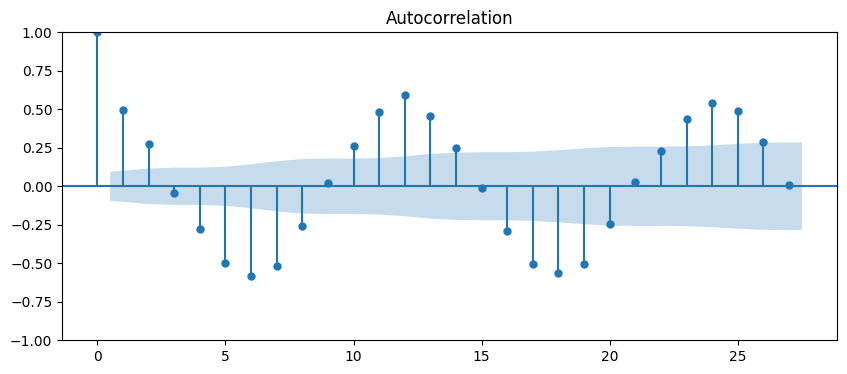

In [111]:
plot_acf(chuva_model)
plt.show()

### Análise de Resíduos

In [112]:
residuos = resultado.resid

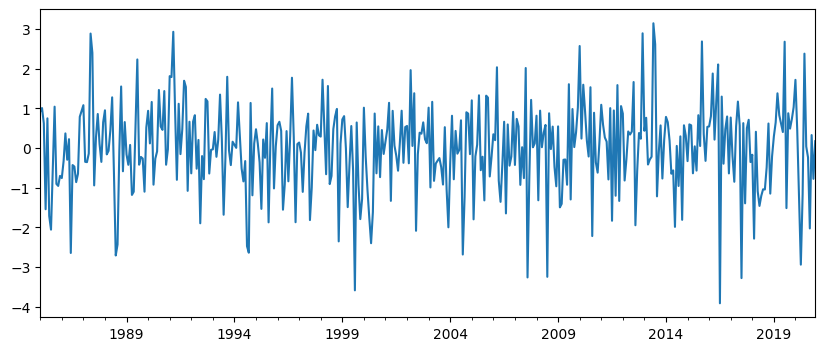

In [113]:
residuos.plot()
plt.show()

O gráfico demonstra oscilação constante em torno da média (zero), indicando que o modelo não possui viés. O comportamento dos resíduos assemelha-se a ruído branco, confirmando que o modelo capturou com sucesso os padrões estruturais dos dados.

### Normalidade

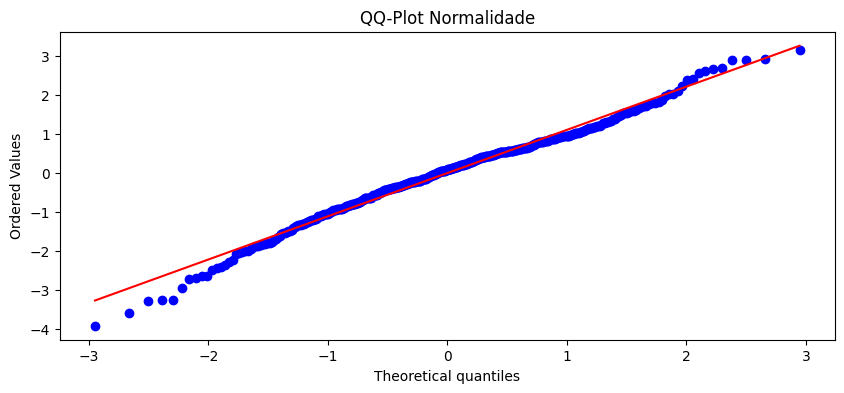

In [114]:
stats.probplot(residuos, dist= 'norm',plot=plt)
plt.title('QQ-Plot Normalidade')
plt.show()

In [115]:
e, p = stats.shapiro(residuos)
print(f"Estatística de teste: {e}")
print(f"p valor: {p}")


Estatística de teste: 0.9866625316156532
p valor: 0.0005365397372787487


Embora o QQ-Plot demonstre visualmente uma forte aderência à normalidade, com a maioria dos pontos sobre a linha teórica, o teste de Shapiro-Wilk rejeita a hipótese nula ($p < 0.05$).

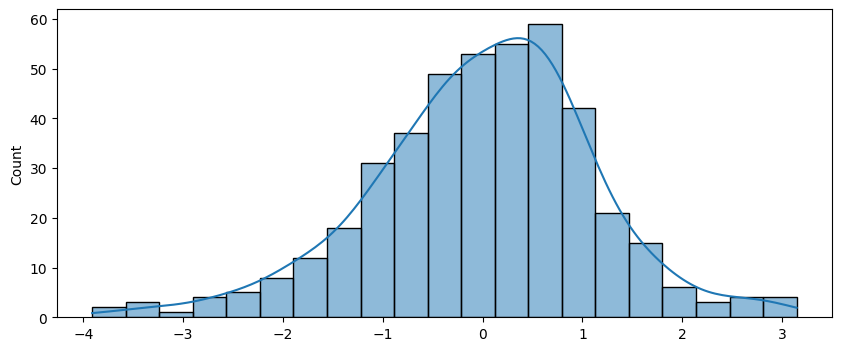

In [116]:
sns.histplot(residuos, kde= True);

### Autocorrelação

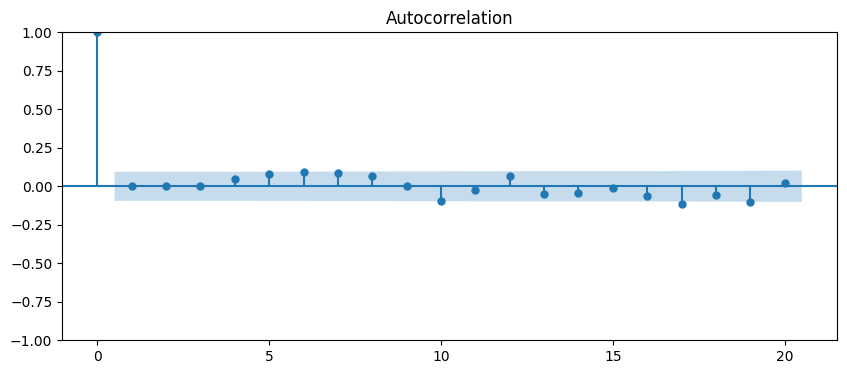

In [117]:
plot_acf(residuos, lags=20)
plt.show()

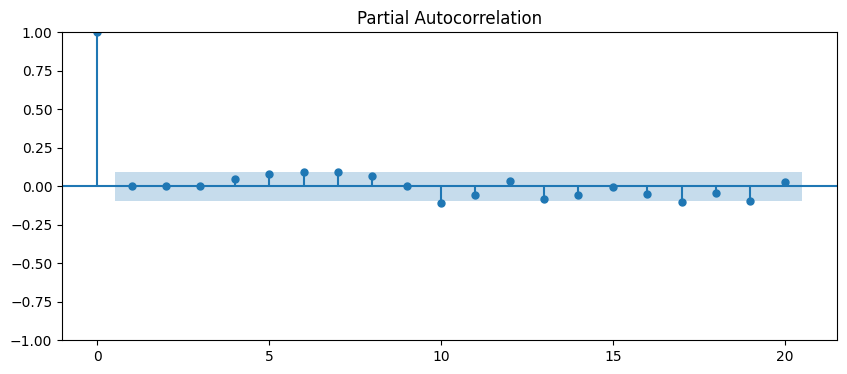

In [118]:
plot_pacf(residuos, lags=20)
plt.show()

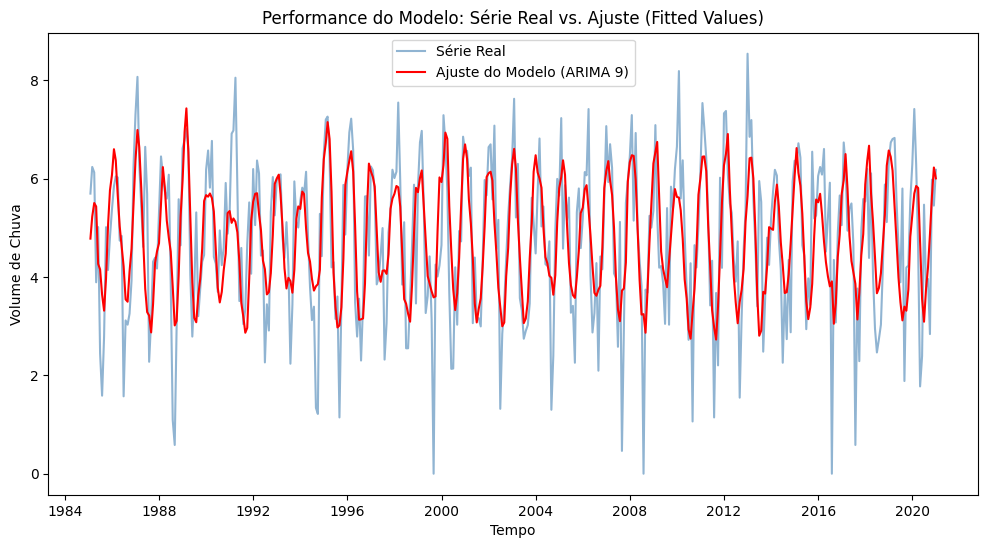

In [119]:
plt.figure(figsize=(12, 6))

plt.plot(chuva_model, label='Série Real', alpha=0.6, color='steelblue')
plt.plot(resultado.fittedvalues, color='red', label='Ajuste do Modelo (ARIMA 9)', linewidth=1.5)

plt.title('Performance do Modelo: Série Real vs. Ajuste (Fitted Values)')
plt.xlabel('Tempo')
plt.ylabel('Volume de Chuva')
plt.legend()
plt.show()

### Previsão

In [120]:
resultado.fittedvalues

,0
1985-01-31,4.781238
1985-02-28,5.230171
1985-03-31,5.505427
1985-04-30,5.434703
1985-05-31,4.266663
...,...
2020-08-31,4.197130
2020-09-30,4.865256
2020-10-31,5.652395
2020-11-30,6.227689


In [121]:
previsao = resultado.predict(431, end=443)
previsao

,predicted_mean
2020-12-31,6.006515
2021-01-31,5.402718
2021-02-28,5.501531
2021-03-31,5.218810
2021-04-30,4.775558
2021-05-31,4.053952
2021-06-30,3.847772
2021-07-31,3.911298
2021-08-31,4.199248
2021-09-30,4.517324


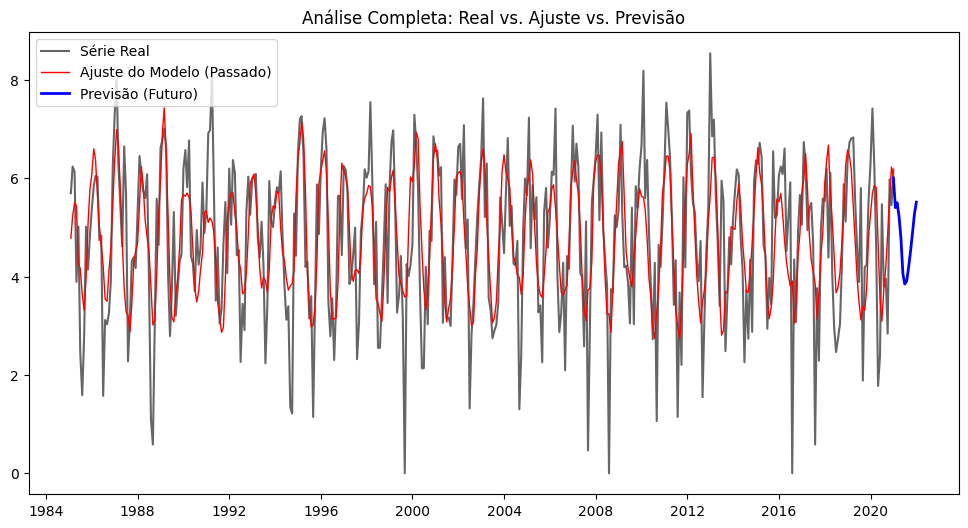

In [122]:
plt.figure(figsize=(12, 6))

# Série Real
plt.plot(chuva_model, color='black', label='Série Real', alpha=0.6)

# Ajuste do Modelo
plt.plot(resultado.fittedvalues, color='red', label='Ajuste do Modelo (Passado)', linewidth=1)

# Previsão
plt.plot(previsao, color='blue', label='Previsão (Futuro)', linewidth=2)

plt.title('Análise Completa: Real vs. Ajuste vs. Previsão')
plt.legend(loc='upper left')
plt.show()

In [123]:
prev_escala = pd.DataFrame(
    data=previsao.values ** 3,
    index=previsao.index,
    columns=['Previsão_AR'])

prev_escala

,Previsão_AR
2020-12-31,216.704344
2021-01-31,157.701867
2021-02-28,166.513965
2021-03-31,142.139391
2021-04-30,108.911170
2021-05-31,66.624801
2021-06-30,56.967627
2021-07-31,59.836001
2021-08-31,74.048218
2021-09-30,92.181479


Previsão com valores em escala real mais serie original

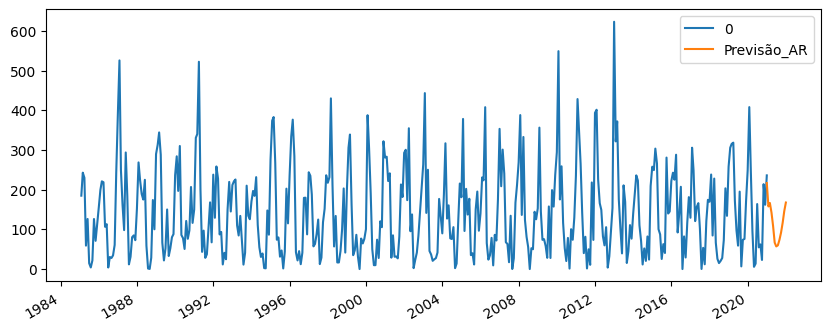

In [124]:
pd.concat([serie_chuva,prev_escala]).plot();

# Modelo MA (Média Movel)

Resultados dos modelos anteriores
* Modelo AR: AIC = 1337.922 (9,0,0)


In [125]:
modelo_ma = ARIMA(chuva_model, order=(0,0,8))

In [126]:
resultado_ma = modelo_ma.fit()
print(resultado_ma.summary())

                               SARIMAX Results                                
Dep. Variable:     chuva_transformada   No. Observations:                  432
Model:                 ARIMA(0, 0, 8)   Log Likelihood                -695.848
Date:                Wed, 04 Feb 2026   AIC                           1411.696
Time:                        19:08:56   BIC                           1452.381
Sample:                    01-31-1985   HQIC                          1427.758
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7863      0.028    172.577      0.000       4.732       4.841
ma.L1          0.3130      0.051      6.129      0.000       0.213       0.413
ma.L2          0.2280      0.051      4.501      0.0

### Análise de Resíduos

In [127]:
residuos_ma = resultado_ma.resid

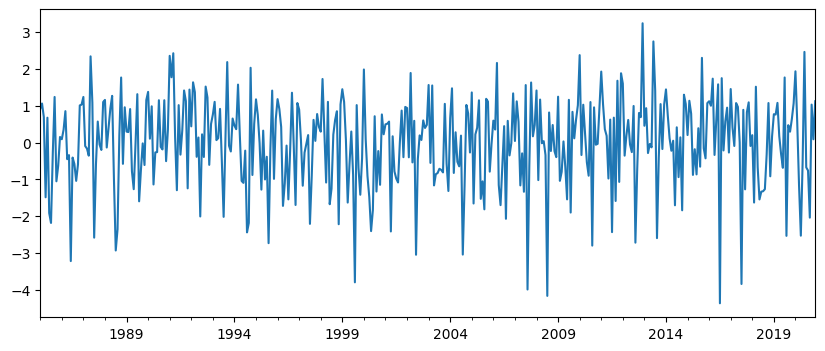

In [128]:
residuos_ma.plot()
plt.show()

### Normalidade

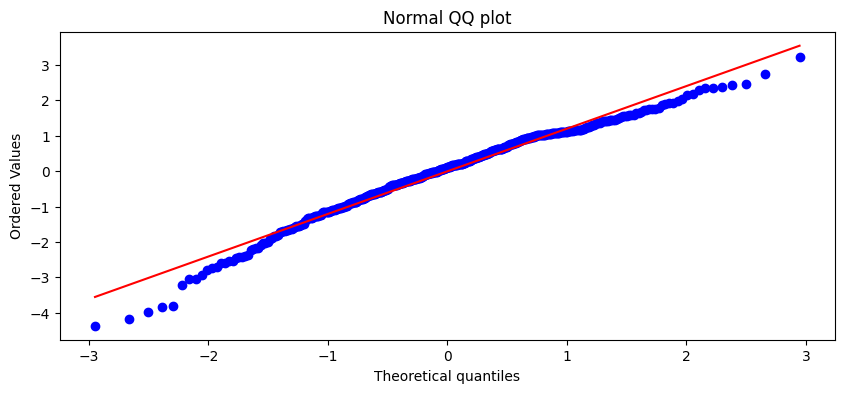

In [129]:
stats.probplot(residuos_ma, dist="norm", plot=plt)
plt.title("Normal QQ plot")
plt.show()

In [130]:
e, p = stats.shapiro(residuos_ma)
print(f"Estatística de teste: {e}")
print(f"p valor: {p}")

Estatística de teste: 0.9771446007136243
p valor: 2.5970675182180595e-06


Distribuição não normal

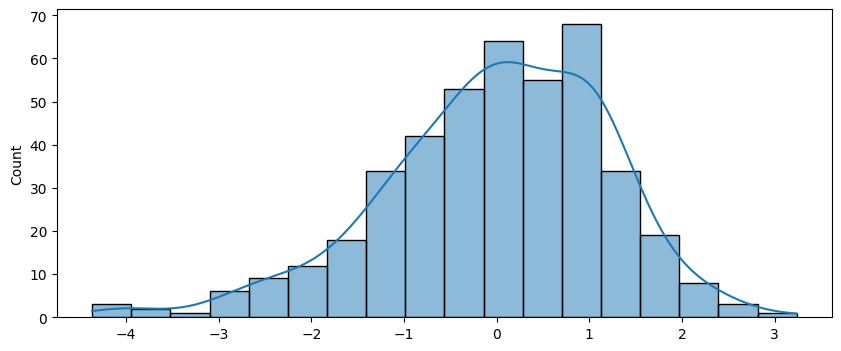

In [131]:
sns.histplot(residuos_ma, kde=True);

### Autocorrelação

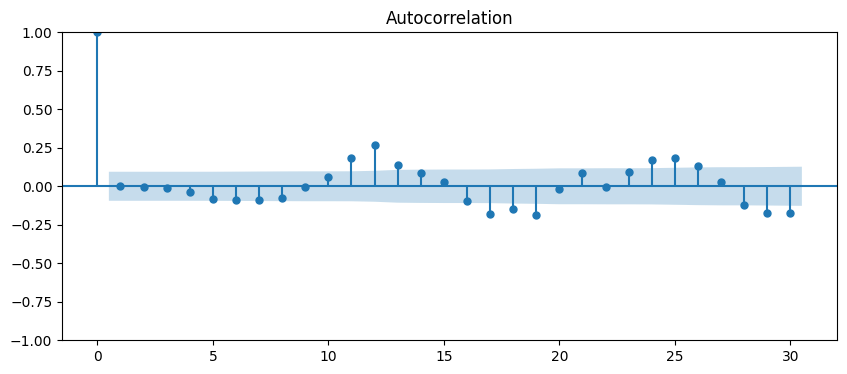

In [132]:
plot_acf(residuos_ma, lags=30)
plt.show()

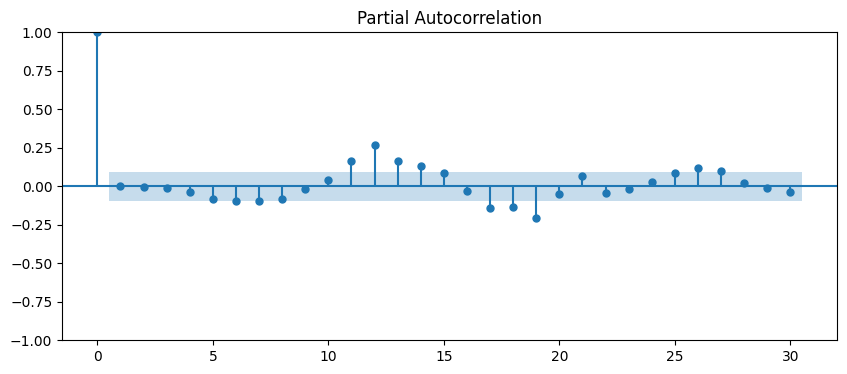

In [133]:
plot_pacf(residuos_ma, lags=30)
plt.show()

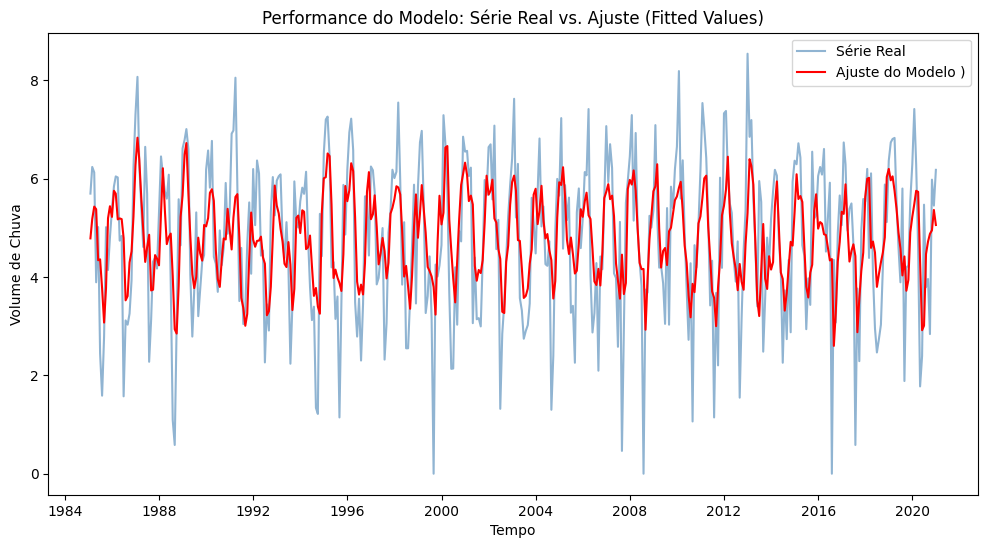

In [134]:
plt.figure(figsize=(12, 6))

plt.plot(chuva_model, label='Série Real', alpha=0.6, color='steelblue')
plt.plot(resultado_ma.fittedvalues, color='red', label='Ajuste do Modelo )', linewidth=1.5)

plt.title('Performance do Modelo: Série Real vs. Ajuste (Fitted Values)')
plt.xlabel('Tempo')
plt.ylabel('Volume de Chuva')
plt.legend()
plt.show()

### Previsão

In [135]:
#valores ajustados
resultado_ma.fittedvalues

,0
1985-01-31,4.786255
1985-02-28,5.179211
1985-03-31,5.432528
1985-04-30,5.379936
1985-05-31,4.341617
...,...
2020-08-31,4.721012
2020-09-30,4.879099
2020-10-31,4.950800
2020-11-30,5.364027


In [136]:
previsao_ma = resultado_ma.predict(start=431, end=443)
previsao_ma

,predicted_mean
2020-12-31,5.058304
2021-01-31,4.956918
2021-02-28,5.533746
2021-03-31,5.497440
2021-04-30,5.113150
2021-05-31,4.416556
2021-06-30,4.281338
2021-07-31,4.394365
2021-08-31,4.647503
2021-09-30,4.786255


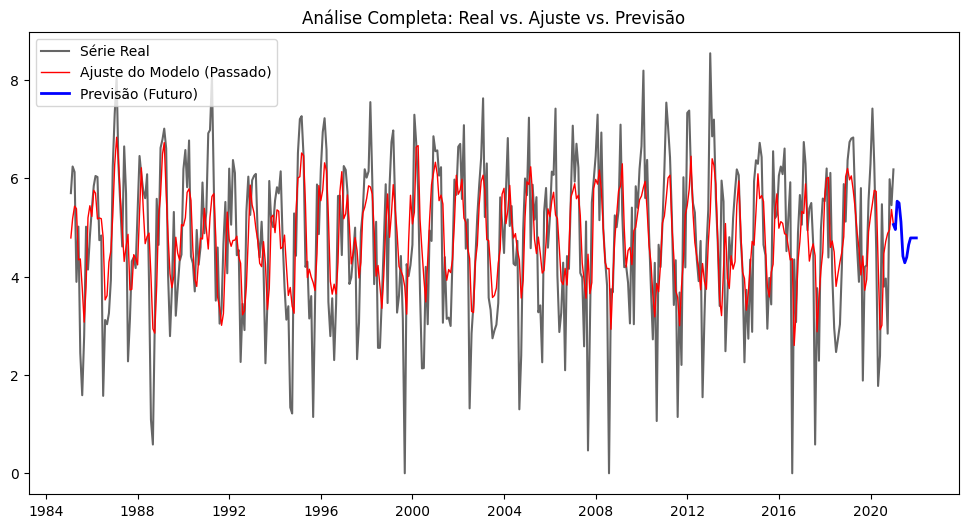

In [137]:
plt.figure(figsize=(12, 6))

# Série Real
plt.plot(chuva_model, color='black', label='Série Real', alpha=0.6)

# Ajuste do Modelo
plt.plot(resultado_ma.fittedvalues, color='red', label='Ajuste do Modelo (Passado)', linewidth=1)

# Previsão
plt.plot(previsao_ma, color='blue', label='Previsão (Futuro)', linewidth=2)

plt.title('Análise Completa: Real vs. Ajuste vs. Previsão')
plt.legend(loc='upper left')
plt.show()

In [138]:
prev_escala_ma = pd.DataFrame(
    data=previsao_ma.values ** 3,
    index=previsao_ma.index,
    columns=['Previsão_MA'])

prev_escala_ma

,Previsão_MA
2020-12-31,129.424020
2021-01-31,121.796577
2021-02-28,169.456270
2021-03-31,166.142804
2021-04-30,133.679738
2021-05-31,86.149196
2021-06-30,78.476327
2021-07-31,84.857141
2021-08-31,100.382754
2021-09-30,109.644636


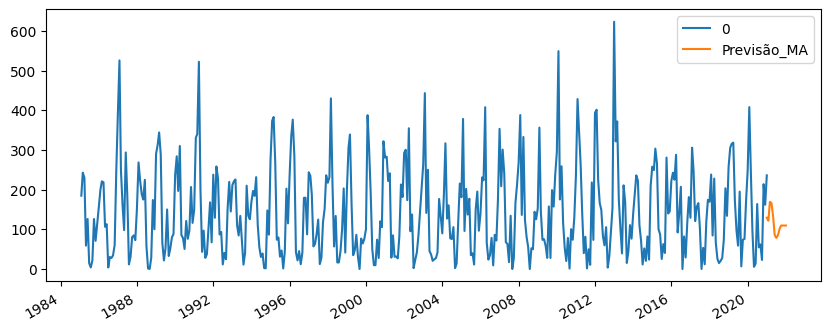

In [139]:
pd.concat([serie_chuva,prev_escala_ma]).plot();

# Modelo ARMA (Auto Regressivo de Média Móvel)

Resultados dos modelos anteriores

* Modelo AR: AIC = 1337.922 (9,0,0)
* Modelo MA: AIC = 1411.696 (0,0,8)



In [140]:
modelo_arma = ARIMA(chuva_model, order = (9,0,3))

In [141]:
resultado_arma = modelo_arma.fit()
print(resultado_arma.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:     chuva_transformada   No. Observations:                  432
Model:                 ARIMA(9, 0, 3)   Log Likelihood                -626.230
Date:                Wed, 04 Feb 2026   AIC                           1280.460
Time:                        19:09:11   BIC                           1337.418
Sample:                    01-31-1985   HQIC                          1302.947
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7890      0.047    102.698      0.000       4.698       4.880
ar.L1          0.7226      0.054     13.367      0.000       0.617       0.829
ar.L2          0.6822      0.075      9.123      0.0

### Análise de Resíduos

In [142]:
residuos_arma = resultado_arma.resid

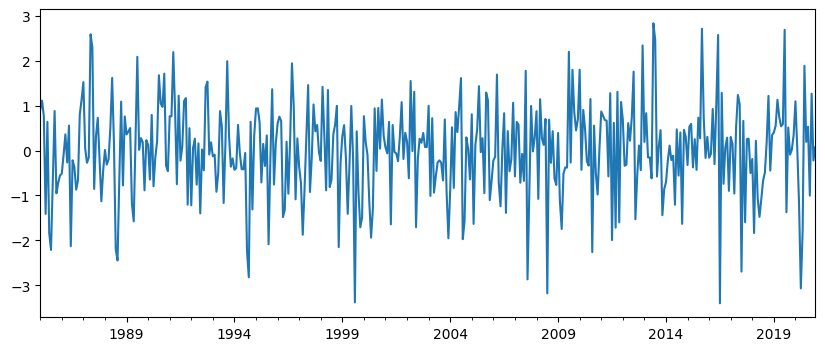

In [143]:
residuos_arma.plot()
plt.show()

### Normalidade

Text(0.5, 1.0, 'Normal QQ plot')

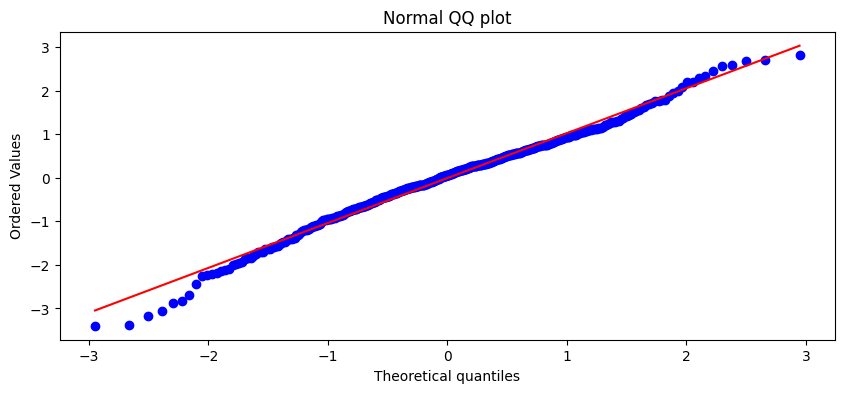

In [144]:
stats.probplot(residuos_arma, dist= 'norm', plot=plt)
plt.title('Normal QQ plot')

In [145]:
e, p = stats.shapiro(residuos_arma)
print(f"Estatística de teste: {e}")
print(f"p valor: {p}")

Estatística de teste: 0.9891696577234392
p valor: 0.002773658691419649


<Axes: ylabel='Count'>

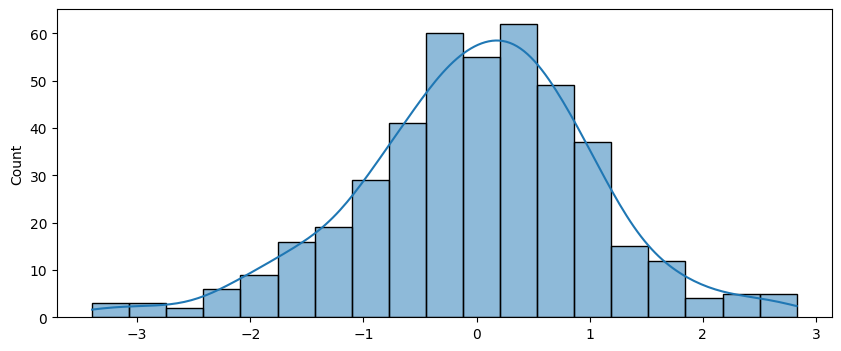

In [146]:
sns.histplot(residuos_arma, kde=True)

### Autocorrelação

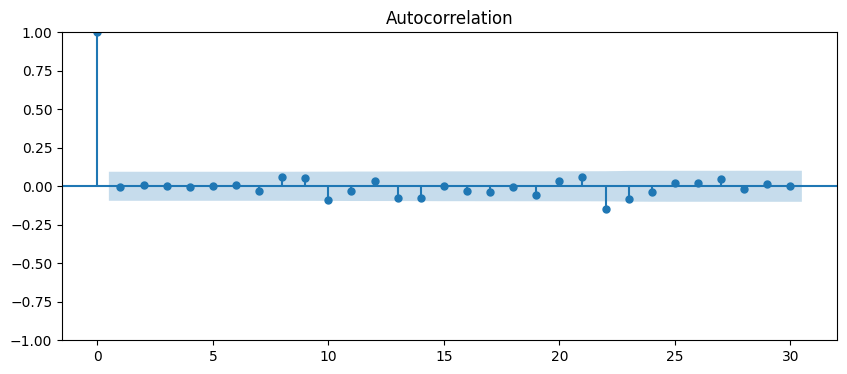

In [147]:
plot_acf(residuos_arma, lags=30)
plt.show()

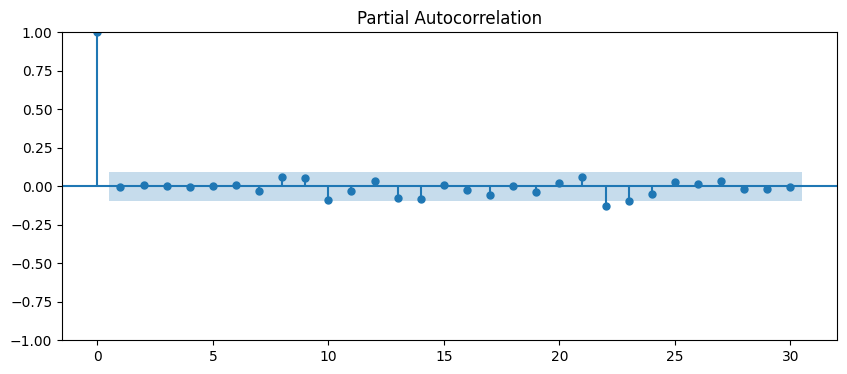

In [148]:
plot_pacf(residuos_arma, lags=30)
plt.show()

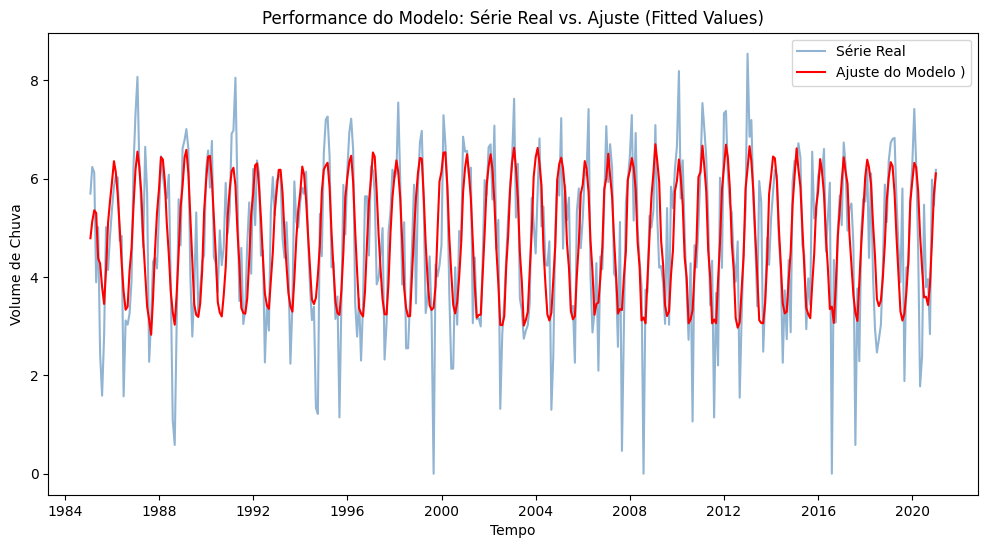

In [149]:
plt.figure(figsize=(12, 6))

plt.plot(chuva_model, label='Série Real', alpha=0.6, color='steelblue')
plt.plot(resultado_arma.fittedvalues, color='red', label='Ajuste do Modelo )', linewidth=1.5)

plt.title('Performance do Modelo: Série Real vs. Ajuste (Fitted Values)')
plt.xlabel('Tempo')
plt.ylabel('Volume de Chuva')
plt.legend()
plt.show()

### Previsão

In [150]:
resultado_arma.fittedvalues

,0
1985-01-31,4.789001
1985-02-28,5.128973
1985-03-31,5.357723
1985-04-30,5.303228
1985-05-31,4.379797
...,...
2020-08-31,3.431465
2020-09-30,3.842957
2020-10-31,4.718037
2020-11-30,5.674278


In [151]:
previsao_arma = resultado_arma.predict(start=431, end=455)
previsao_arma

,predicted_mean
2020-12-31,6.108044
2021-01-31,6.238592
2021-02-28,6.071040
2021-03-31,5.613427
2021-04-30,4.721273
2021-05-31,4.037122
2021-06-30,3.417141
2021-07-31,3.288712
2021-08-31,3.445547
2021-09-30,4.067297


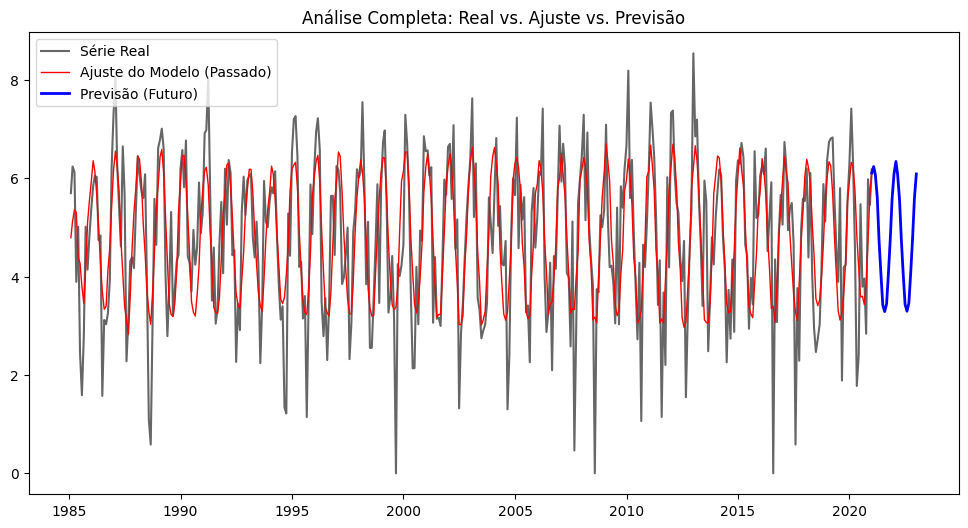

In [152]:
plt.figure(figsize=(12, 6))

# Série Real
plt.plot(chuva_model, color='black', label='Série Real', alpha=0.6)

# Ajuste do Modelo
plt.plot(resultado_arma.fittedvalues, color='red', label='Ajuste do Modelo (Passado)', linewidth=1)

# Previsão
plt.plot(previsao_arma, color='blue', label='Previsão (Futuro)', linewidth=2)

plt.title('Análise Completa: Real vs. Ajuste vs. Previsão')
plt.legend(loc='upper left')
plt.show()

In [153]:
prev_escala_arma = pd.DataFrame(
    data=previsao_arma.values ** 3,
    index=previsao_arma.index,
    columns=['Previsão_ARMA'])

prev_escala_arma

,Previsão_ARMA
2020-12-31,227.880155
2021-01-31,242.806139
2021-02-28,223.763526
2021-03-31,176.882287
2021-04-30,105.239142
2021-05-31,65.798447
2021-06-30,39.901453
2021-07-31,35.569467
2021-08-31,40.904815
2021-09-30,67.284916


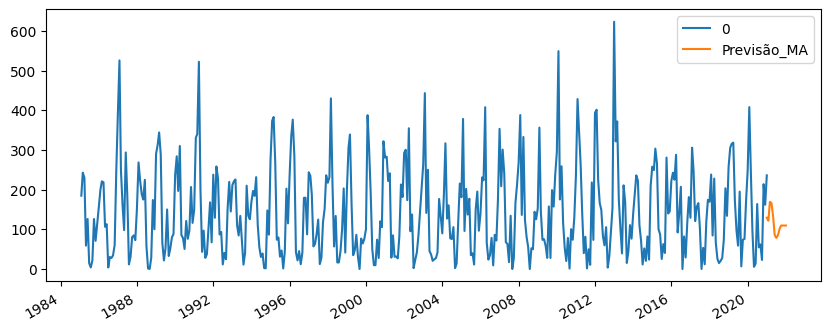

In [154]:
pd.concat([serie_chuva,prev_escala_ma]).plot();

# Modelo ARIMA (Auto Regressivo Integrado de Média Móvel)

Resultados dos modelos anteriores

* Modelo AR: AIC = 1337.922 (9,0,0)
* Modelo MA: AIC = 1411.696 (0,0,8)
* Modelo ARMA: AIC = 1280.460 (9,0,3)


In [155]:
modelo_arima = ARIMA(chuva_model, order= (10,1,2))

In [156]:
resultado_arima = modelo_arima.fit()
print(resultado_arima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:     chuva_transformada   No. Observations:                  432
Model:                ARIMA(10, 1, 2)   Log Likelihood                -649.995
Date:                Wed, 04 Feb 2026   AIC                           1325.990
Time:                        19:09:18   BIC                           1378.849
Sample:                    01-31-1985   HQIC                          1346.861
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7044      0.067     10.583      0.000       0.574       0.835
ar.L2         -0.2257      0.065     -3.448      0.001      -0.354      -0.097
ar.L3         -0.2938      0.073     -4.015      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [157]:
residuos_arima = resultado_arima.resid


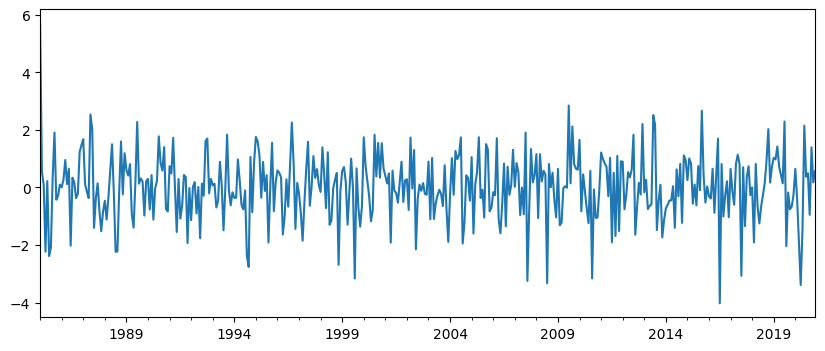

In [158]:
residuos_arima.plot()
plt.show()

### Normalidade

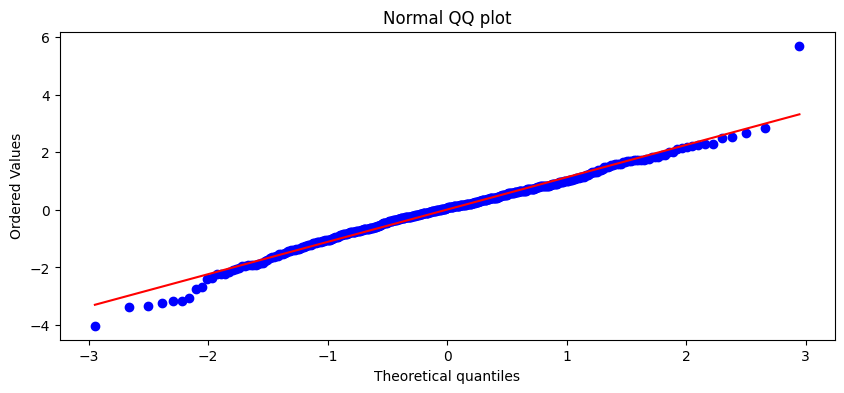

In [159]:
stats.probplot(residuos_arima, dist='norm', plot=plt)
plt.title('Normal QQ plot')
plt.show()

In [160]:
e, p = stats.shapiro(residuos_arima)
print('Estatística de teste: {}'.format(e))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9819238172014351
p-valor: 3.212910851805625e-05


<Axes: ylabel='Count'>

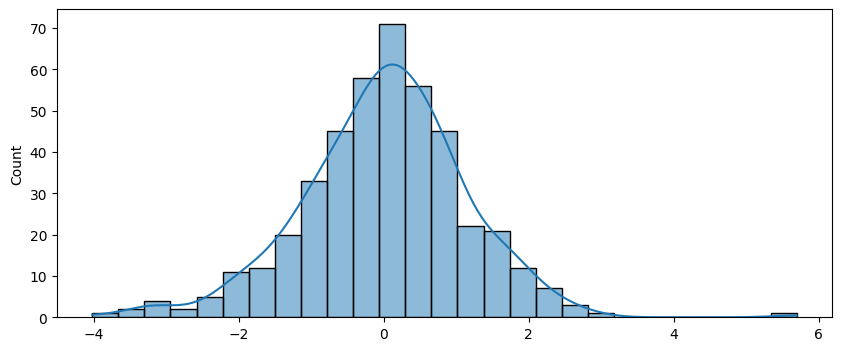

In [161]:
sns.histplot(residuos_arima, kde= True)

### Autocorrelação

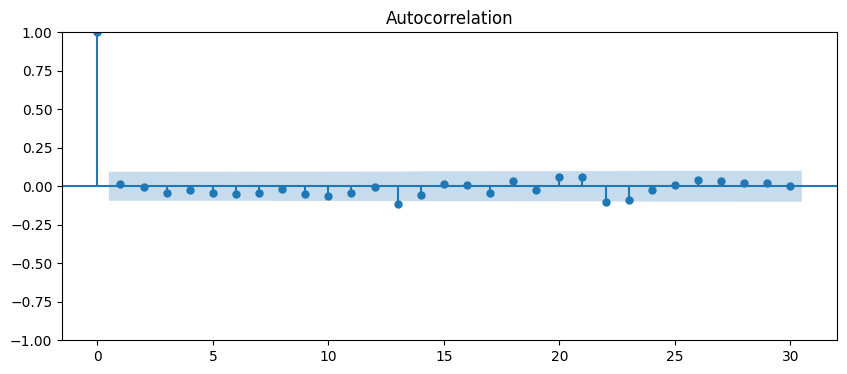

In [162]:
plot_acf(residuos_arima, lags=30)
plt.show()

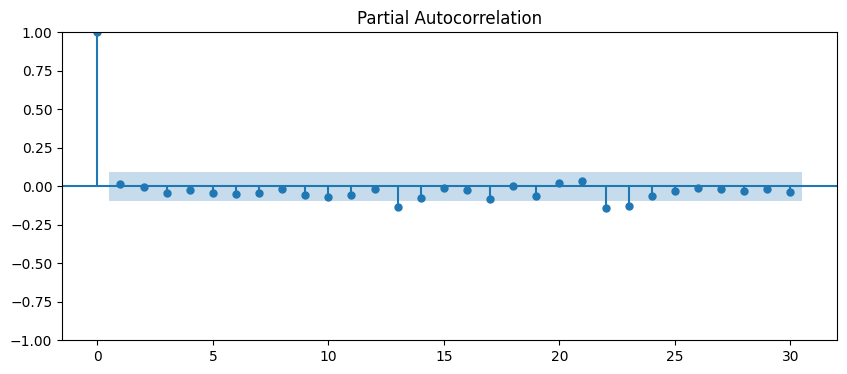

In [163]:
plot_pacf(residuos_arima, lags=30)
plt.show()

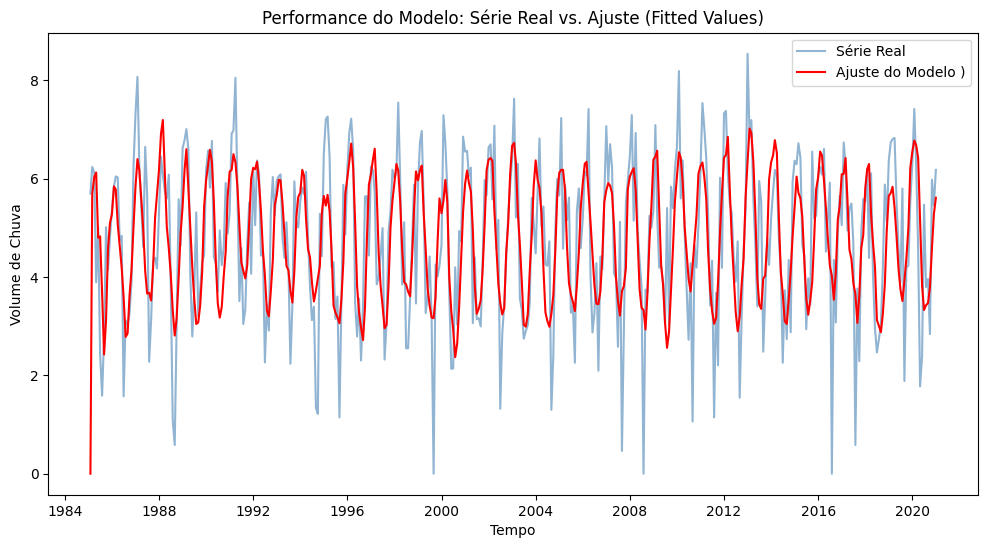

In [164]:
plt.figure(figsize=(12, 6))

plt.plot(chuva_model, label='Série Real', alpha=0.6, color='steelblue')
plt.plot(resultado_arima.fittedvalues, color='red', label='Ajuste do Modelo )', linewidth=1.5)

plt.title('Performance do Modelo: Série Real vs. Ajuste (Fitted Values)')
plt.xlabel('Tempo')
plt.ylabel('Volume de Chuva')
plt.legend()
plt.show()

### Previsão

In [165]:
resultado_arima.fittedvalues

,0
1985-01-31,0.000000
1985-02-28,5.696987
1985-03-31,6.031986
1985-04-30,6.126549
1985-05-31,4.798626
...,...
2020-08-31,3.469864
2020-09-30,3.791552
2020-10-31,4.589574
2020-11-30,5.280332


In [166]:
previsao_arima = resultado_arima.predict(start=430, end=443)
previsao_arima

,predicted_mean
2020-11-30,5.280332
2020-12-31,5.612283
2021-01-31,5.530939
2021-02-28,5.983214
2021-03-31,5.513314
2021-04-30,4.565061
2021-05-31,3.641843
2021-06-30,3.382049
2021-07-31,3.550071
2021-08-31,3.762525


In [167]:
previsao_arima2 = resultado_arima.forecast(24)


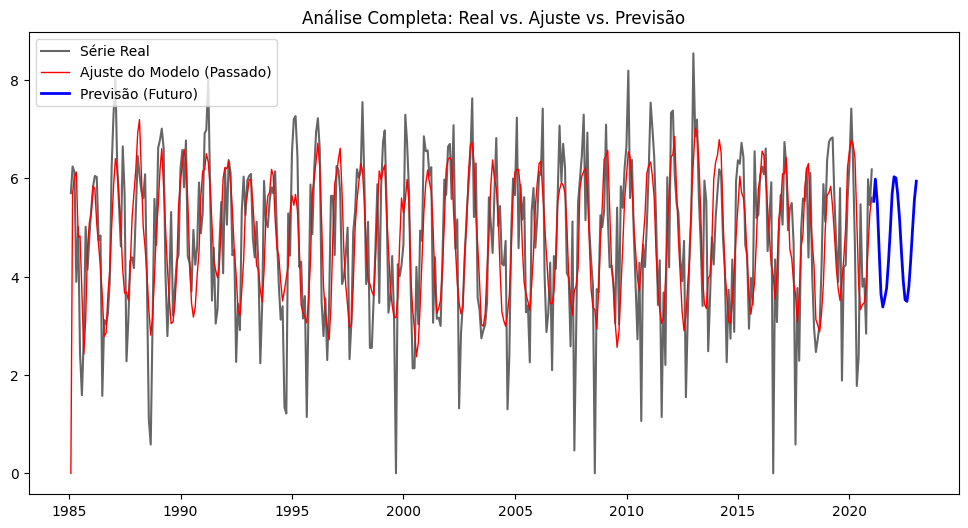

In [168]:
plt.figure(figsize=(12, 6))

# Série Real
plt.plot(chuva_model, color='black', label='Série Real', alpha=0.6)

# Ajuste do Modelo
plt.plot(resultado_arima.fittedvalues, color='red', label='Ajuste do Modelo (Passado)', linewidth=1)

# Previsão
plt.plot(previsao_arima2, color='blue', label='Previsão (Futuro)', linewidth=2)

plt.title('Análise Completa: Real vs. Ajuste vs. Previsão')
plt.legend(loc='upper left')
plt.show()

In [169]:
prev_escala_arima = pd.DataFrame(
    data=previsao_arima2.values ** 3,
    index=previsao_arima2.index,
    columns=['Previsão_ARIMA'])

prev_escala_arima

,Previsão_ARIMA
2021-01-31,169.198523
2021-02-28,214.192206
2021-03-31,167.586132
2021-04-30,95.134877
2021-05-31,48.301857
2021-06-30,38.684746
2021-07-31,44.741575
2021-08-31,53.264535
2021-09-30,78.483807
2021-10-31,121.586949


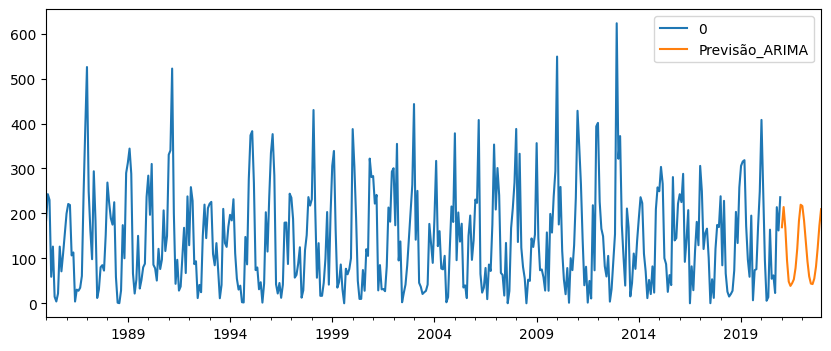

In [170]:
pd.concat([serie_chuva,prev_escala_arima]).plot();

# Modelo SARIMA (Média Móvel Integrada Autorregressiva Sazonal)

Resultados dos modelos anteriores

* Modelo AR: AIC = 1337.922 (9,0,0)
* Modelo MA: AIC = 1411.696 (0,0,8)
* Modelo ARMA: AIC = 1280.460 (9,0,3)
* Modelo ARIMA:AIC = 1325.990 (10,1,2)

In [171]:
modelo_auto = auto_arima(chuva_model, trace = True, stepwise = False, seasonal=True, max_p=10, max_q=10,
                          max_P=4, max_Q=4, start_p=0, start_q=0, start_P=0, start_Q=0, m=12,)

# Trace: apresenta no console a lista dos modelos.
# stepwise: seleção gradual porém menos minusioso.
# m: período sazonal (neste caso mensal).

 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1618.370, Time=0.03 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=1503.636, Time=0.31 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=1474.263, Time=0.91 sec
 ARIMA(0,0,0)(0,0,3)[12] intercept   : AIC=1437.044, Time=2.11 sec
 ARIMA(0,0,0)(0,0,4)[12] intercept   : AIC=1419.293, Time=3.78 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=1427.651, Time=1.06 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=2.90 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=4.80 sec
 ARIMA(0,0,0)(1,0,3)[12] intercept   : AIC=1270.160, Time=10.21 sec
 ARIMA(0,0,0)(1,0,4)[12] intercept   : AIC=inf, Time=18.89 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=1385.579, Time=1.95 sec
 ARIMA(0,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=2.86 sec
 ARIMA(0,0,0)(2,0,2)[12] intercept   : AIC=1278.476, Time=5.13 sec
 ARIMA(0,0,0)(2,0,3)[12] intercept   : AIC=inf, Time=10.86 sec
 ARIMA(0,0,0)(3,0,0)[12] intercept   : AIC=inf, Time=7.87 sec
 ARIMA(0,0,0)(3,0,1)[1

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning: Error fitting  ARIMA(0,0,0)(3,0,2)[12] intercept (if you do not want to see these warnings, run with error_action="ignore").
Traceback:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py", line 508, in _fit_candidate_model
    fit.fit(y, X=X, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 610, in fit
    self._fit(y, X, **fit_args)
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 531, in _fit
    fit, self.arima_res_ = _fit_wrapper()
                           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 517, in _fit_wrapper
    fitted = arima.fit(
             ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py", line 705, in fit
    mlefit = super().fit(start_p

 ARIMA(0,0,0)(3,0,2)[12] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(4,0,0)[12] intercept   : AIC=inf, Time=19.27 sec


/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning: Error fitting  ARIMA(0,0,0)(4,0,1)[12] intercept (if you do not want to see these warnings, run with error_action="ignore").
Traceback:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py", line 508, in _fit_candidate_model
    fit.fit(y, X=X, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 610, in fit
    self._fit(y, X, **fit_args)
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 531, in _fit
    fit, self.arima_res_ = _fit_wrapper()
                           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 517, in _fit_wrapper
    fitted = arima.fit(
             ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py", line 705, in fit
    mlefit = super().fit(start_p

 ARIMA(0,0,0)(4,0,1)[12] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=1534.551, Time=0.10 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1464.951, Time=0.44 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=1448.732, Time=1.07 sec
 ARIMA(0,0,1)(0,0,3)[12] intercept   : AIC=1418.891, Time=2.29 sec
 ARIMA(0,0,1)(0,0,4)[12] intercept   : AIC=1406.458, Time=6.66 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=1419.367, Time=0.79 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=inf, Time=1.84 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=4.41 sec
 ARIMA(0,0,1)(1,0,3)[12] intercept   : AIC=1279.427, Time=11.58 sec
 ARIMA(0,0,1)(2,0,0)[12] intercept   : AIC=1383.694, Time=2.28 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=3.36 sec
 ARIMA(0,0,1)(2,0,2)[12] intercept   : AIC=inf, Time=7.42 sec
 ARIMA(0,0,1)(3,0,0)[12] intercept   : AIC=1340.191, Time=6.44 sec
 ARIMA(0,0,1)(3,0,1)[12] intercept   : AIC=inf, Time=8.43 sec
 ARIMA(0,0,1)(4,0,0)[12] 

Best model:  ARIMA(0,0,0)(1,0,3)[12] intercept
Total fit time: 461.634 seconds

In [172]:
print(modelo_auto.aic())

1270.1600047729833


In [173]:
resultado_auto = modelo_auto.fit(chuva_model)
print(resultado_auto.summary())

                                    SARIMAX Results                                     
Dep. Variable:                                y   No. Observations:                  432
Model:             SARIMAX(1, 0, [1, 2, 3], 12)   Log Likelihood                -629.080
Date:                          Wed, 04 Feb 2026   AIC                           1270.160
Time:                                  19:17:20   BIC                           1294.571
Sample:                              01-31-1985   HQIC                          1279.797
                                   - 12-31-2020                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0257      0.017      1.540      0.124      -0.007       0.058
ar.S.L12       0.9946      0.004    275.343      0.

### Análise dos Resíduos

In [174]:
residuos_auto = resultado_auto.resid
residuos_auto()

,0
1985-01-31,0.982132
1985-02-28,1.524535
1985-03-31,1.412065
1985-04-30,-0.821864
1985-05-31,0.301089
...,...
2020-08-31,1.030856
2020-09-30,-1.119414
2020-10-31,1.221765
2020-11-30,0.158479


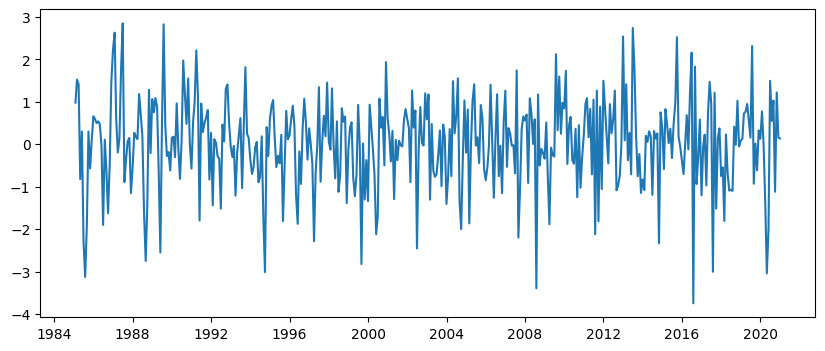

In [175]:
plt.plot(residuos_auto())
plt.show()

### Normalidade

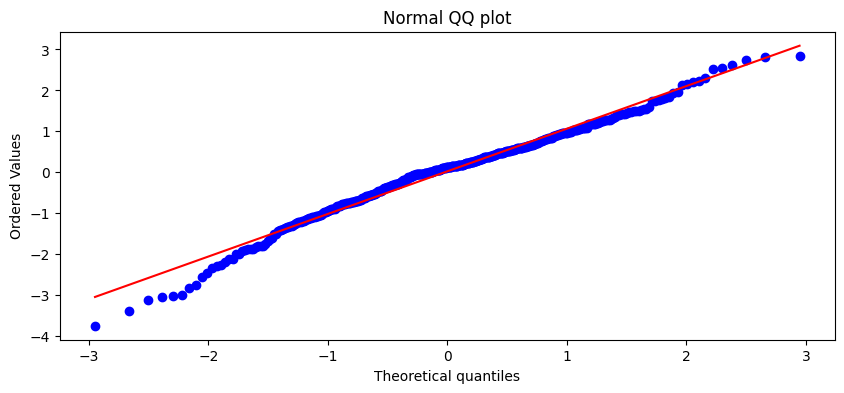

In [176]:
stats.probplot(residuos_auto(), dist="norm", plot=plt)
plt.title("Normal QQ plot")
plt.show()

In [177]:
e, p = stats.shapiro(residuos_auto())
print('Estatística de teste: {}'.format(e))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9822528325637737
p-valor: 3.863108648341259e-05


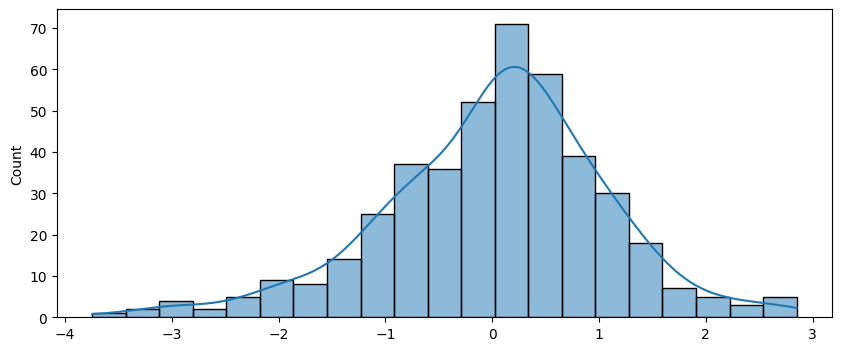

In [178]:
sns.histplot(residuos_auto(), kde=True)
plt.show()

# Autocorrelação

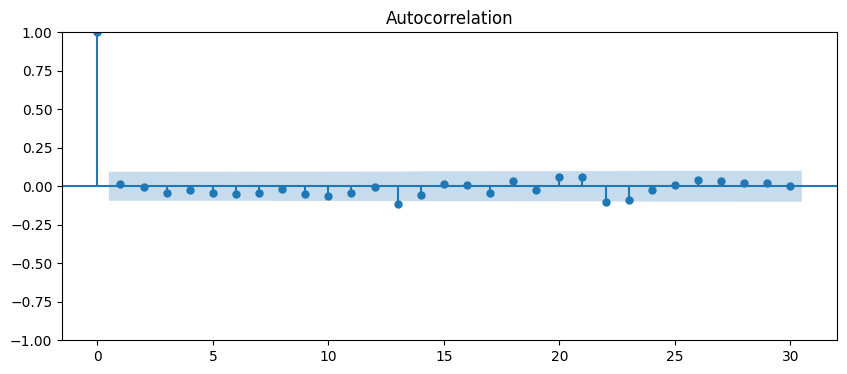

In [179]:
plot_acf(residuos_arima, lags=30)
plt.show()

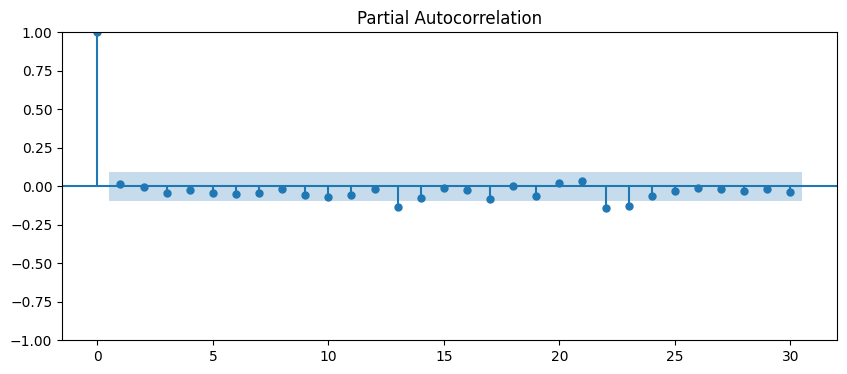

In [180]:
plot_pacf(residuos_arima, lags=30)
plt.show()

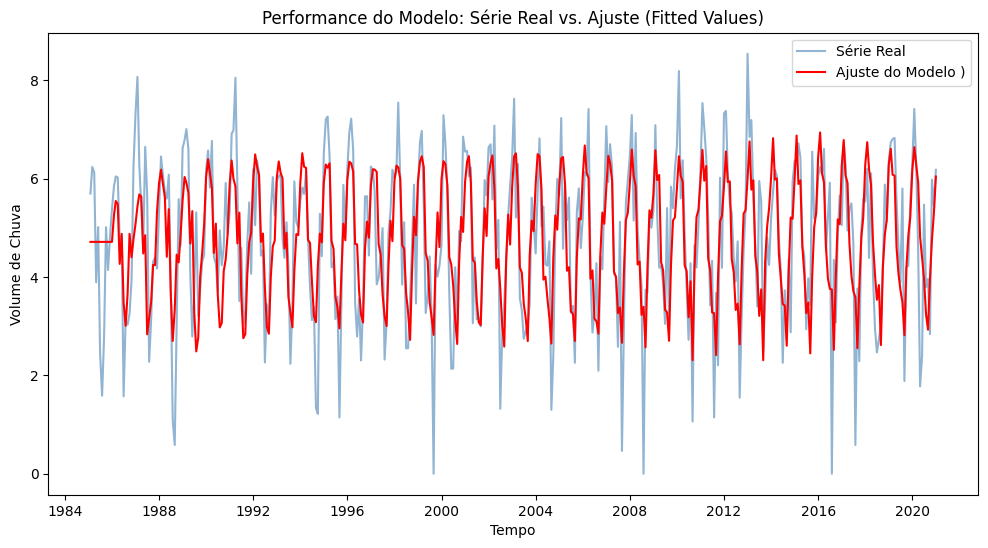

In [181]:
plt.figure(figsize=(12, 6))

plt.plot(chuva_model, label='Série Real', alpha=0.6, color='steelblue')
plt.plot(resultado_auto.fittedvalues(), color='red', label='Ajuste do Modelo )', linewidth=1.5)

plt.title('Performance do Modelo: Série Real vs. Ajuste (Fitted Values)')
plt.xlabel('Tempo')
plt.ylabel('Volume de Chuva')
plt.legend()
plt.show()

# Previsão

In [182]:
previsao_auto = resultado_auto.predict(n_periods=48)
previsao_auto

,0
2021-01-31,6.575384
2021-02-28,5.955121
2021-03-31,5.830953
2021-04-30,4.504163
2021-05-31,4.105381
2021-06-30,3.876431
2021-07-31,2.927415
2021-08-31,3.121737
2021-09-30,3.909799
2021-10-31,5.013697


In [183]:
prev_escala_auto = pd.DataFrame(
    data=previsao_auto.values ** 3,
    index=previsao_auto.index,
    columns=['Previsão_SARIMA'])

prev_escala_auto

,Previsão_SARIMA
2021-01-31,284.291121
2021-02-28,211.189183
2021-03-31,198.252433
2021-04-30,91.378119
2021-05-31,69.192723
2021-06-30,58.250053
2021-07-31,25.087234
2021-08-31,30.422085
2021-09-30,59.767263
2021-10-31,126.030066


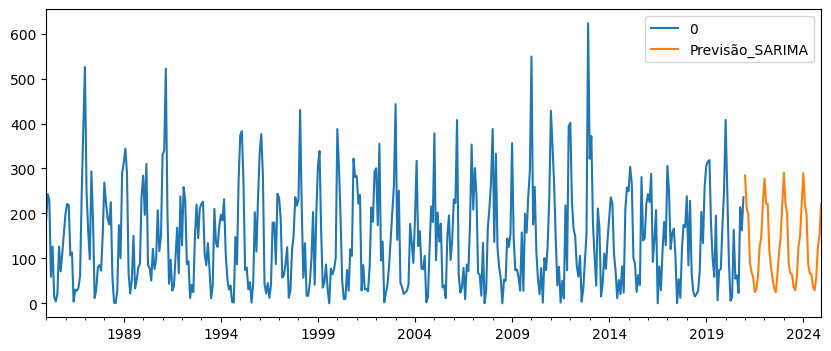

In [184]:
pd.concat([serie_chuva,prev_escala_auto]).plot();

Resultados dos modelos anteriores

* Modelo AR: AIC = 1337.922 (9,0,0)
* Modelo MA: AIC = 1411.696 (0,0,8)
* Modelo ARMA: AIC = 1280.460 (9,0,3)
* Modelo ARIMA: AIC = 1325.990 (10,1,2)
* **Modelo SARIMA: AIC = 1270.16 (0,0,0) (1,0,3**)

# Métricas dos modelos

Estou usando os valores da base de dados do ano de 2021 (Jan até Abr) para validação dos modelos e interpretação das métricas.

In [185]:
#valores reais de 2021
lista = [373.3, 174.1, 137.8, 55.7]
valores_reais = pd.DataFrame(lista, columns = ['valores reais'])
print(valores_reais)

   valores reais
0          373.3
1          174.1
2          137.8
3           55.7


In [186]:
#SARIMA - Média Móvel Integrada Autorregressiva Sazonal
auto = prev_escala_auto.iloc[0:4]
auto

,Previsão_SARIMA
2021-01-31,284.291121
2021-02-28,211.189183
2021-03-31,198.252433
2021-04-30,91.378119


In [187]:
auto.reset_index(drop=True, inplace=True)

In [188]:
desempenho= pd.concat( [valores_reais, auto], axis=1)
desempenho

,valores reais,Previsão_SARIMA
0,373.3,284.291121
1,174.1,211.189183
2,137.8,198.252433
3,55.7,91.378119


In [189]:
# AR - Auto Regressivo
ar = prev_escala.iloc[1:5]
ar

,Previsão_AR
2021-01-31,157.701867
2021-02-28,166.513965
2021-03-31,142.139391
2021-04-30,108.911170


In [190]:
pd.DataFrame.reset_index(ar, drop=True, inplace=True)
ar

,Previsão_AR
0,157.701867
1,166.513965
2,142.139391
3,108.911170


In [191]:
# MA - Média Móvel
ma = prev_escala_ma.iloc[1:5]
ma

,Previsão_MA
2021-01-31,121.796577
2021-02-28,169.456270
2021-03-31,166.142804
2021-04-30,133.679738


In [192]:
pd.DataFrame.reset_index(ma, drop=True, inplace=True)
ma

,Previsão_MA
0,121.796577
1,169.456270
2,166.142804
3,133.679738


In [193]:
#ARMA - Autorregressivo de Média Móvel
arma = prev_escala_arma.iloc[1:5]
arma

,Previsão_ARMA
2021-01-31,242.806139
2021-02-28,223.763526
2021-03-31,176.882287
2021-04-30,105.239142


In [194]:
pd.DataFrame.reset_index(arma, drop=True, inplace=True)
arma

,Previsão_ARMA
0,242.806139
1,223.763526
2,176.882287
3,105.239142


In [195]:
#ARIMA - Auto Regressivo Integrado de Média Móvel
arima = prev_escala_arima.iloc[0:4]
arima

,Previsão_ARIMA
2021-01-31,169.198523
2021-02-28,214.192206
2021-03-31,167.586132
2021-04-30,95.134877


In [196]:
pd.DataFrame.reset_index(arima, drop=True, inplace=True)
arima

,Previsão_ARIMA
0,169.198523
1,214.192206
2,167.586132
3,95.134877


Concatenar todas


In [197]:
desempenho = pd.concat([desempenho, ar, ma, arma, arima],axis=1)
desempenho

,valores reais,Previsão_SARIMA,Previsão_AR,Previsão_MA,Previsão_ARMA,Previsão_ARIMA
0,373.3,284.291121,157.701867,121.796577,242.806139,169.198523
1,174.1,211.189183,166.513965,169.456270,223.763526,214.192206
2,137.8,198.252433,142.139391,166.142804,176.882287,167.586132
3,55.7,91.378119,108.911170,133.679738,105.239142,95.134877


### Erro médio Absoluto - MAE

É a média aritmética das diferenças absolutas entre o real e o previsto.

In [198]:
print ("Erro Médio Absoluto - MAE")

mae_sarima = mean_absolute_error(desempenho['valores reais'], desempenho['Previsão_SARIMA'])
print(f"Resultado Sarima: {mae_sarima}")

mae_ar= mean_absolute_error(desempenho['valores reais'], desempenho['Previsão_AR'])
print(f"Resultado AR: {mae_ar}")

mae_ma= mean_absolute_error(desempenho['valores reais'], desempenho['Previsão_MA'])
print(f"Resultado MA: {mae_ma}")

mae_arma = mean_absolute_error(desempenho['valores reais'], desempenho['Previsão_ARMA'])
print(f"Resultado ARMA: {mae_arma}")

mae_arima= mean_absolute_error(desempenho['valores reais'], desempenho['Previsão_ARIMA'])
print(f"Resultado ARiMA: {mae_arima}")

Erro Médio Absoluto - MAE
Resultado Sarima: 55.557153559527336
Resultado AR: 70.18368226785003
Resultado MA: 90.6174238215616
Resultado ARMA: 67.19470421417562
Resultado ARiMA: 78.35367279305125


### Erro Quadrático Médio - MSE

Eleva o erro ao quadrado antes de aplicar a média, potencializando os erros

In [199]:
print('Erro Quadrático Médio - MSE')
mse_sarima = mean_squared_error(desempenho['valores reais'], desempenho['Previsão_SARIMA'])
print(f"Resultado Sarima: {mse_sarima}")
mse_ar = mean_squared_error(desempenho['valores reais'], desempenho['Previsão_AR'])
print(f"Resultado AR: {mse_ar}")
mse_ma = mean_squared_error(desempenho['valores reais'], desempenho['Previsão_MA'])
print(f"Resultado MA: {mse_ma}")
mse_arma = mean_squared_error(desempenho['valores reais'], desempenho['Previsão_ARMA'])
print(f"Resultado ARMA: {mse_arma}")
mse_arima = mean_squared_error(desempenho['valores reais'], desempenho['Previsão_ARIMA'])
print(f"Resultado ARIMA: {mse_arima}")

Erro Quadrático Médio - MSE
Resultado Sarima: 3556.4032222930173
Resultado AR: 12347.590486706087
Resultado MA: 17539.922538952014
Resultado ARMA: 5869.166368450988
Resultado ARIMA: 11426.780212098556


Raiz do erro Quadrático Médio - RMSE

É a raiz quadrada do MSE, voltando à unidade original (milímetros)

In [200]:
print('Erro Quadrático Médio - RMSE')
rmse_sarima = root_mean_squared_error(desempenho['valores reais'], desempenho['Previsão_SARIMA'])
print(f"Resultado Sarima: {rmse_sarima}")
rmse_ar = root_mean_squared_error(desempenho['valores reais'], desempenho['Previsão_AR'])
print(f"Resultado AR: {rmse_ar}")
rmse_ma = root_mean_squared_error(desempenho['valores reais'], desempenho['Previsão_MA'])
print(f"Resultado MA: {rmse_ma}")
rmse_arma = root_mean_squared_error(desempenho['valores reais'], desempenho['Previsão_ARMA'])
print(f"Resultado ARMA: {rmse_arma}")
rmse_arima = root_mean_squared_error(desempenho['valores reais'], desempenho['Previsão_ARIMA'])
print(f"Resultado ARIMA: {rmse_arima}")

Erro Quadrático Médio - RMSE
Resultado Sarima: 59.63558687807991
Resultado AR: 111.11971241281219
Resultado MA: 132.43837260760952
Resultado ARMA: 76.61048471619918
Resultado ARIMA: 106.89611878875003


# Análise das Métricas
Fica evidenciada, mediante as métricas analisadas, a superioridade do modelo SARIMA (obtido via Auto ARIMA), tanto em precisão de previsão quanto em qualidade de ajuste. Este modelo destaca-se devido à sua capacidade de capturar a sazonalidade, uma característica marcante do regime de chuvas no estado de São Paulo. O baixo valor de AIC (1270.16) confirma que a inclusão dos termos sazonais permitiu ao modelo representar os padrões anuais identificados na análise estatística inicial (ACF/PACF) de forma eficiente, sem causar overfitting.

### Análise de Picos Extremos (Janeiro de 2021):
 A superioridade do SARIMA fica ainda mais clara ao observarmos a capacidade de prever eventos extremos. Em janeiro, o volume real de chuva foi de 373.3 mm, um pico significativamente superior aos meses seguintes.

* O SARIMA foi o único a acompanhar a tendência de alta, prevendo 284.3 mm (Diferença de ~89 mm).

* O ARMA ficou em segundo lugar, prevendo 242.8 mm (Diferença de ~130 mm).

* Os modelos sem componente de média móvel ou sazonalidade falharam em capturar o evento: o ARIMA previu apenas 169.2 mm (erro de ~204 mm) e o AR previu 157.7 mm (erro de ~215 mm).

* O pior desempenho no pico foi do modelo MA, que previu apenas 121.8 mm, subestimando a chuva real em mais de 250 mm."

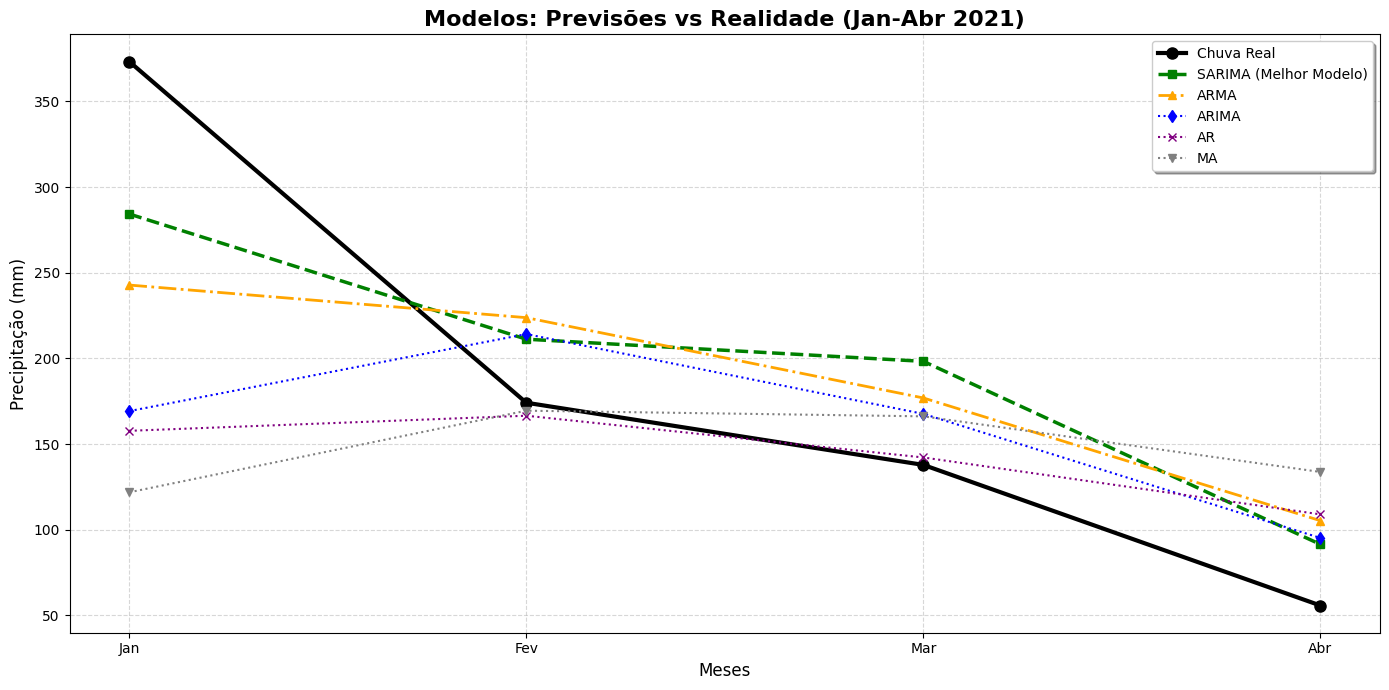

In [206]:
plt.figure(figsize=(14, 7))


plt.plot(desempenho['valores reais'], label='Chuva Real', color='black', linewidth=3, marker='o', markersize=8)


plt.plot(desempenho['Previsão_SARIMA'], label='SARIMA (Melhor Modelo)', color='green', linestyle='--', linewidth=2.5, marker='s')

plt.plot(desempenho['Previsão_ARMA'], label='ARMA', color='orange', linestyle='-.', linewidth=2, marker='^')

plt.plot(desempenho['Previsão_ARIMA'], label='ARIMA', color='blue', linestyle=':', linewidth=1.5, marker='d')
plt.plot(desempenho['Previsão_AR'], label='AR', color='purple', linestyle=':', linewidth=1.5, marker='x')
plt.plot(desempenho['Previsão_MA'], label='MA', color='gray', linestyle=':', linewidth=1.5, marker='v')


plt.title('Modelos: Previsões vs Realidade (Jan-Abr 2021)', fontsize=16, fontweight='bold')
plt.xlabel('Meses', fontsize=12)
plt.ylabel('Precipitação (mm)', fontsize=12)

plt.xticks(range(len(desempenho)), ['Jan', 'Fev', 'Mar', 'Abr'])

plt.legend(loc='best', fontsize=10, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [205]:

tabela_erros = pd.DataFrame()

tabela_erros['Chuva Real'] = desempenho['valores reais']

lista_modelos = ['SARIMA', 'AR', 'MA', 'ARMA', 'ARIMA']

for modelo in lista_modelos:
    nome_coluna_previsao = f'Previsão_{modelo}'

    # Cálculo: Real - Previsão
    # Positivo = Modelo Subestimou (chuva na previsão)
    # Negativo = Modelo Superestimou (chuva demais)
    tabela_erros[f'Dif {modelo}'] = desempenho['valores reais'] - desempenho[nome_coluna_previsao]


tabela_erros.index = ['Janeiro', 'Fevereiro', 'Março', 'Abril']
tabela_erros = tabela_erros.round(2)

print("Tabela de Diferenças (Real - Previsão):")
display(tabela_erros)

Tabela de Diferenças (Real - Previsão):


,Chuva Real,Dif SARIMA,Dif AR,Dif MA,Dif ARMA,Dif ARIMA
Janeiro,373.3,89.01,215.60,251.50,130.49,204.10
Fevereiro,174.1,-37.09,7.59,4.64,-49.66,-40.09
Março,137.8,-60.45,-4.34,-28.34,-39.08,-29.79
Abril,55.7,-35.68,-53.21,-77.98,-49.54,-39.43


Embora modelos como o AR tenham apresentado resíduos menores nos meses (fevereiro e março) ele demonstra ser instável para previsões de eventos críticos, falhando em capturar o pico de chuvas de janeiro com erro de 215mm.

O SARIMA, por outro lado, provou ser o modelo mais robusto. Embora tenha apresentado uma tendência a superestimar a chuva nos meses de queda (resíduos negativos em Fev/Mar), essa característica conservadora permitiu que ele fosse o único modelo capaz de antecipar o grande volume de chuvas em Janeiro (erro de apenas 89 mm), tornando-o a escolha segura para o planeamento hidrológico.